# 3E - Estabilidade: o sinal vale antes e depois da mudanca de regime?

**Pergunta especifica.** As relacoes que sobreviveram ao 3D valem em 1993-2009 E em 2010-presente, ou dependem de um regime especifico do Pacifico?

**Objetivo.** Aplicar o filtro final do protocolo e fechar o conjunto defensavel (= 3D interseccao 3E).

**Justificativa.** O Pacifico mudou de comportamento ~2010 (enfraquecimento do lead do WWV, documentado). Testar dois subperiodos protege contra sinais de epoca.

**Metodologia.** Reavaliar cada sobrevivente do 3D no seu melhor lag, em 1993-2009 e 2010-hoje. Estavel = mesmo sinal e p_efetivo<0.05 em ambos.

**Saidas.** `phase3E_estabilidade.csv` + scatter r1 x r2 e mapas lon x lag por subperiodo.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
best=pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
def cat(wd,v,lag):
    x=wd[v].shift(lag); y=wd['nino34_ssta']; m=x.notna()&y.notna()
    if m.sum()<80: return np.nan,np.nan
    r=float(np.corrcoef(x[m],y[m])[0,1]); return r,correlation_p_value(r,effective_sample_size(x[m].values,y[m].values))
rows=[]
for v,row in best.iterrows():
    lag=int(row['lag_semanas'])
    r1,p1=cat(w.loc['1993-01-01':'2009-12-31'],v,lag); r2,p2=cat(w.loc['2010-01-01':],v,lag)
    rows.append({'variavel':v,'lag_semanas':lag,'r_full':round(row['r'],3),'r_1993_2009':round(r1,3),'p_1993_2009':round(p1,4),'r_2010_hoje':round(r2,3),'p_2010_hoje':round(p2,4),'estavel':bool((np.sign(r1)==np.sign(r2)) and p1<0.05 and p2<0.05)})
est=pd.DataFrame(rows).set_index('variavel'); u.save_table(est,'phase3E_estabilidade.csv')
print('ESTABILIDADE por variavel:')
for v,r in est.iterrows(): print(f"  {v:22s} lag{int(r.lag_semanas):2d}  r(93-09)={r.r_1993_2009:+.2f}(p={r.p_1993_2009:.3f})  r(10-hoje)={r.r_2010_hoje:+.2f}(p={r.p_2010_hoje:.3f})  {'ESTAVEL' if r.estavel else 'INSTAVEL'}")

[tabela] data\processed\parquet\statistics\phase3E_estabilidade.csv
ESTABILIDADE por variavel:
  tilt_m                 lag 0  r(93-09)=+0.80(p=0.001)  r(10-hoje)=+0.81(p=0.001)  ESTAVEL
  ssh_m                  lag 6  r(93-09)=+0.78(p=0.000)  r(10-hoje)=+0.76(p=0.001)  ESTAVEL
  ohc_0_300              lag 6  r(93-09)=+0.74(p=0.001)  r(10-hoje)=+0.73(p=0.002)  ESTAVEL
  ohc_0_700              lag 6  r(93-09)=+0.71(p=0.002)  r(10-hoje)=+0.69(p=0.002)  ESTAVEL
  dhw_cweek_p90          lag 0  r(93-09)=+0.53(p=0.084)  r(10-hoje)=+0.66(p=0.034)  INSTAVEL
  d20_m                  lag15  r(93-09)=+0.55(p=0.032)  r(10-hoje)=+0.53(p=0.040)  ESTAVEL
  wwv                    lag20  r(93-09)=+0.56(p=0.048)  r(10-hoje)=+0.48(p=0.110)  INSTAVEL
  tau_x_anom_nino34_pa   lag 1  r(93-09)=+0.47(p=0.000)  r(10-hoje)=+0.53(p=0.000)  ESTAVEL


[figura] data\processed\figures\fase3\phase3E_scatter_estabilidade.png


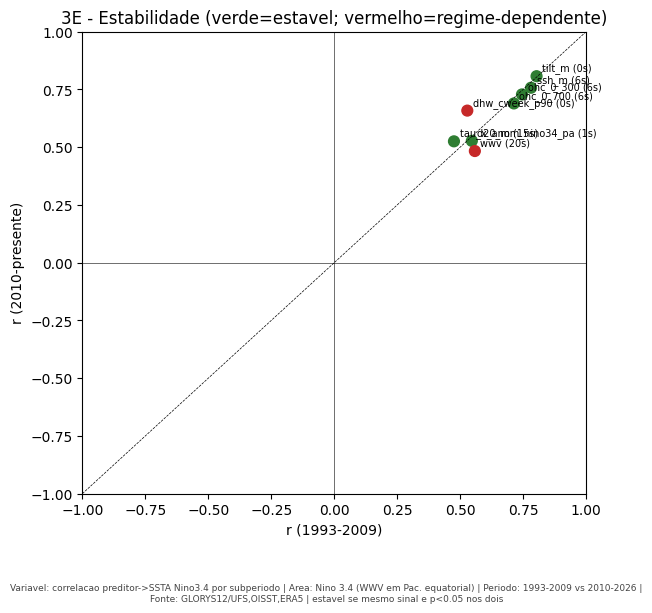

In [2]:
fig,ax=plt.subplots(figsize=(6.5,6))
cores=est['estavel'].map({True:'#2e7d32',False:'#c62828'})
ax.scatter(est['r_1993_2009'],est['r_2010_hoje'],c=cores,s=60)
for v,r in est.iterrows(): ax.annotate(f"{v} ({int(r.lag_semanas)}s)",(r['r_1993_2009'],r['r_2010_hoje']),fontsize=7,xytext=(4,4),textcoords='offset points')
ax.plot([-1,1],[-1,1],'k--',lw=.5); ax.axhline(0,color='k',lw=.4); ax.axvline(0,color='k',lw=.4); ax.set_xlim(-1,1); ax.set_ylim(-1,1)
ax.set_xlabel('r (1993-2009)'); ax.set_ylabel('r (2010-presente)'); ax.set_title('3E - Estabilidade (verde=estavel; vermelho=regime-dependente)')
u.stamp_caption(fig,variavel='correlacao preditor->SSTA Nino3.4 por subperiodo',area='Nino 3.4 (WWV em Pac. equatorial)',periodo='1993-2009 vs 2010-2026',fonte='GLORYS12/UFS,OISST,ERA5',extra='estavel se mesmo sinal e p<0.05 nos dois')
u.save_fig(fig,'phase3E_scatter_estabilidade.png'); plt.show()

[tabela] data\processed\parquet\statistics\phase3E_mapa_diff_resumo.csv


[figura] data\processed\figures\fase3\phase3E_mapa_lon_lag_subperiodos.png


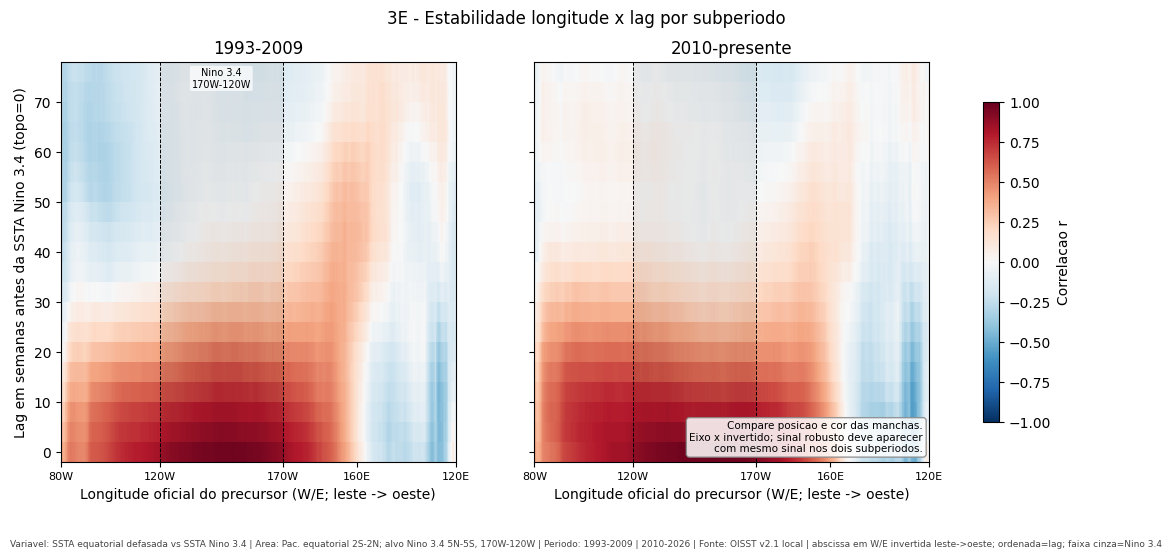

In [3]:
eq=u.load_eqband_weekly(); tgt=w['nino34_ssta']
def ll(eqd,tg,lags):
    a,tt=eqd.align(tg,join='inner',axis=0); tv=tt.values; out=np.full((len(lags),a.shape[1]),np.nan)
    for i,lag in enumerate(lags):
        sh=a.shift(lag).values
        for j in range(a.shape[1]):
            x=sh[:,j]; m=np.isfinite(x)&np.isfinite(tv)
            if m.sum()>80: out[i,j]=np.corrcoef(x[m],tv[m])[0,1]
    return out,a.columns.values
lags=list(range(0,79,4))
A,lon=ll(eq.loc['1993-01-01':'2009-12-31'],tgt.loc['1993-01-01':'2009-12-31'],lags)
B,_=ll(eq.loc['2010-01-01':],tgt.loc['2010-01-01':],lags)
fig,axes=plt.subplots(1,2,figsize=(14,5.2),sharey=True)
for ax,mat,tt in [(axes[0],A,'1993-2009'),(axes[1],B,'2010-presente')]:
    pc=ax.pcolormesh(lon,lags,mat,cmap='RdBu_r',vmin=-1,vmax=1,shading='auto')
    u.add_nino34_lon_band(ax,label=(ax is axes[0]))
    u.format_lon_axis(ax, xlabel='Longitude oficial do precursor (W/E; leste -> oeste)')
    ax.invert_yaxis(); ax.set_title(tt)
axes[0].set_ylabel('Lag em semanas antes da SSTA Nino 3.4 (topo=0)')
fig.suptitle('3E - Estabilidade longitude x lag por subperiodo')
fig.colorbar(pc,ax=axes,label='Correlacao r',shrink=.8)
u.add_note(axes[1],'Compare posicao e cor das manchas.\nEixo x invertido; sinal robusto deve aparecer\ncom mesmo sinal nos dois subperiodos.',loc='lower right')
u.stamp_caption(fig,variavel='SSTA equatorial defasada vs SSTA Nino 3.4',area='Pac. equatorial 2S-2N; alvo Nino 3.4 5N-5S, 170W-120W',periodo='1993-2009 | 2010-2026',fonte='OISST v2.1 local',extra='abscissa em W/E invertida leste->oeste; ordenada=lag; faixa cinza=Nino 3.4')
u.save_table(pd.DataFrame({'diff_medio_abs':[float(np.nanmean(np.abs(A-B)))]}),'phase3E_mapa_diff_resumo.csv',index=False)
u.save_fig(fig,'phase3E_mapa_lon_lag_subperiodos.png'); plt.show()


**Leitura do 3E.** Conjunto defensavel (estavel nos dois regimes): **tilt, SSH, OHC 0-300/0-700, D20 (~15 sem, o melhor precursor), tau_x_anom**. **Regime-dependentes (entram com ressalva):** WWV (perde significancia pos-2010, p~0.11 - reproduz de forma independente o achado da literatura) e DHW C-week P90. Relacao instavel e *achado*, nao lixo: e limitacao de regime a declarar no parecer.